# Food Delivery Clustering — Practical Evaluation

A **3-stage pipeline** modelled on Zomato/Swiggy dispatch logic, centered on the user's location.

| Stage | Problem | K | Why it's interesting |
|-------|---------|---|----------------------|
| 1 | Geo-zone clustering of restaurants | 6 | Pure spatial; OriginScale's origin-anchored init should dominate |
| 2 | Restaurant segmentation within zones | 4 | Mixed features (cuisine, price, rating); GMM vs KMeans boundary |
| 3 | Delivery executive dispatch (real-time) | 8 | Init speed is the metric — re-clusters every few seconds |

Dataset is **synthetically generated** to mimic Bengaluru geography but the pipeline generalises.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, Birch, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

SEED = 42
rng  = np.random.default_rng(SEED)

print('Libraries loaded.')

Libraries loaded.


## OriginScale initialiser

Key idea: instead of sampling initial centroids from the data distribution (KMeans++) or uniform random,
OriginScale places them deterministically using the **centre-of-mass** of the dataset as its anchor,
then scales outward by equal angular slices. This makes it:

- **O(n)** vs O(nk) for KMeans++
- **Deterministic** — no random seed needed
- **Naturally biased toward the user** when the user location is the true geometric centre

In [3]:
def originscale_init(X: np.ndarray, k: int) -> np.ndarray:
    """
    OriginScale centroid initialisation.
    Returns (k, n_features) array of initial centroids.
    """
    origin = X.mean(axis=0)           # geometric centre (= user location for geo data)
    diffs  = X - origin               # vectors from origin to every point
    dists  = np.linalg.norm(diffs, axis=1)
    scale  = dists.mean()             # characteristic radius

    # Place k centroids evenly on a circle of radius `scale` around the origin
    angles    = np.linspace(0, 2 * np.pi, k, endpoint=False)
    centroids = np.column_stack([
        origin[i] + scale * (np.cos(angles) if i == 0 else np.sin(angles))
        for i in range(X.shape[1])
    ])

    # For higher-dimensional data: first 2 dims get the circle, rest get origin value
    if X.shape[1] > 2:
        extra = np.tile(origin[2:], (k, 1))
        centroids = np.hstack([centroids[:, :2], extra])

    return centroids


def run_originscale(X: np.ndarray, k: int, **kwargs):
    """Full KMeans run with OriginScale init."""
    init = originscale_init(X, k)
    km   = KMeans(n_clusters=k, init=init, n_init=1, random_state=SEED, **kwargs)
    km.fit(X)
    return km

print('OriginScale defined.')

OriginScale defined.


## Dataset generation

We simulate a 10 km × 10 km area centred at the user (0, 0 in normalised coords).
Restaurants are drawn from **6 realistic neighbourhood clusters** (Koramangala, Indiranagar,
HSR Layout, Whitefield, Jayanagar, MG Road) with realistic density differences.

Each restaurant has:
- `lat`, `lng` — location (normalised degrees offset)
- `cuisine_code` — 0-7 one-hot encoded as a float
- `rating` — 1.0–5.0
- `avg_price` — ₹100–₹2000
- `delivery_time_min` — 15–60 min
- `orders_last_hour` — proxy for demand

Delivery executives have:
- `lat`, `lng`
- `idle_time_min` — 0–30
- `orders_completed_today` — experience proxy

In [4]:
# ─── Neighbourhood definitions (lat_offset, lng_offset from user, approx 1 unit ≈ 1 km) ───
NEIGHBOURHOODS = {
    'Koramangala': {'centre': (-0.5,  0.8), 'n': 80, 'spread': 0.3},
    'Indiranagar': {'centre': ( 1.2,  1.5), 'n': 65, 'spread': 0.35},
    'HSR Layout':  {'centre': (-1.5,  0.2), 'n': 70, 'spread': 0.4},
    'Whitefield':  {'centre': ( 2.8,  2.2), 'n': 45, 'spread': 0.5},
    'Jayanagar':   {'centre': (-0.8, -1.8), 'n': 55, 'spread': 0.4},
    'MG Road':     {'centre': ( 0.3,  0.5), 'n': 85, 'spread': 0.25},
}

CUISINES = ['Indian', 'Chinese', 'Italian', 'South Indian', 'Fast Food', 'Biryani', 'Continental', 'Desserts']

def generate_restaurants(seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for zone_id, (name, cfg) in enumerate(NEIGHBOURHOODS.items()):
        n = cfg['n']
        cx, cy = cfg['centre']
        s = cfg['spread']

        lats = rng.normal(cx, s, n)
        lngs = rng.normal(cy, s, n)

        # Cuisine distribution varies by neighbourhood (realistic)
        cuisine_weights = rng.dirichlet(np.ones(8) * 2)
        cuisines = rng.choice(len(CUISINES), n, p=cuisine_weights)

        # Rating clusters: premium areas (MG Road, Indiranagar) skew higher
        rating_mean = 4.1 if name in ('MG Road', 'Indiranagar') else 3.6
        ratings = np.clip(rng.normal(rating_mean, 0.4, n), 1.0, 5.0)

        # Price range tied to neighbourhood character
        price_mean = 800 if name in ('MG Road', 'Whitefield', 'Indiranagar') else 350
        prices = np.clip(rng.normal(price_mean, price_mean * 0.3, n), 100, 2000)

        delivery_times = np.clip(rng.normal(30, 8, n), 15, 60)
        orders_last_hr = rng.poisson(lam=12 if name in ('MG Road', 'Koramangala') else 6, size=n)

        for i in range(n):
            rows.append({
                'restaurant_id': f'R{len(rows):04d}',
                'name': f'{CUISINES[cuisines[i]]} Place #{len(rows):03d}',
                'neighbourhood': name,
                'true_zone': zone_id,
                'lat': lats[i],
                'lng': lngs[i],
                'cuisine': CUISINES[cuisines[i]],
                'cuisine_code': int(cuisines[i]),
                'rating': round(ratings[i], 1),
                'avg_price': round(prices[i]),
                'delivery_time_min': round(delivery_times[i], 1),
                'orders_last_hour': int(orders_last_hr[i]),
            })
    return pd.DataFrame(rows)


def generate_delivery_execs(n=120, seed=SEED):
    """Active delivery executives scattered around the city, denser near user."""
    rng = np.random.default_rng(seed)
    # 60% clustered near restaurant zones, 40% truly scattered
    zone_centres = np.array([cfg['centre'] for cfg in NEIGHBOURHOODS.values()])
    assignments  = rng.integers(0, len(zone_centres), n)
    noise        = rng.normal(0, 0.4, (n, 2))
    positions    = zone_centres[assignments] + noise

    return pd.DataFrame({
        'exec_id': [f'E{i:04d}' for i in range(n)],
        'lat': positions[:, 0],
        'lng': positions[:, 1],
        'idle_time_min': np.clip(rng.exponential(8, n), 0, 30).round(1),
        'orders_completed_today': rng.integers(0, 20, n),
        'is_available': rng.random(n) > 0.15,  # ~85% available
    })


restaurants = generate_restaurants()
execs       = generate_delivery_execs()

print(f'Restaurants: {len(restaurants)} across {restaurants["neighbourhood"].nunique()} zones')
print(f'Delivery execs: {len(execs)} ({execs["is_available"].sum()} available)')
print()
restaurants.head()

Restaurants: 400 across 6 zones
Delivery execs: 120 (105 available)



,restaurant_id,name,neighbourhood,true_zone,lat,lng,cuisine,cuisine_code,rating,avg_price,delivery_time_min,orders_last_hour
0,R0000,South Indian Place #000,Koramangala,0,-0.408585,0.937033,South Indian,3,3.5,509,18.1,16
1,R0001,Biryani Place #001,Koramangala,0,-0.811995,0.601422,Biryani,5,3.7,417,15.0,10
2,R0002,Biryani Place #002,Koramangala,0,-0.274865,0.691084,Biryani,5,4.3,277,24.6,8
3,R0003,Italian Place #003,Koramangala,0,-0.217831,0.685479,Italian,2,3.2,244,36.0,15
4,R0004,Chinese Place #004,Koramangala,0,-1.085311,0.441248,Chinese,1,3.5,353,27.7,11


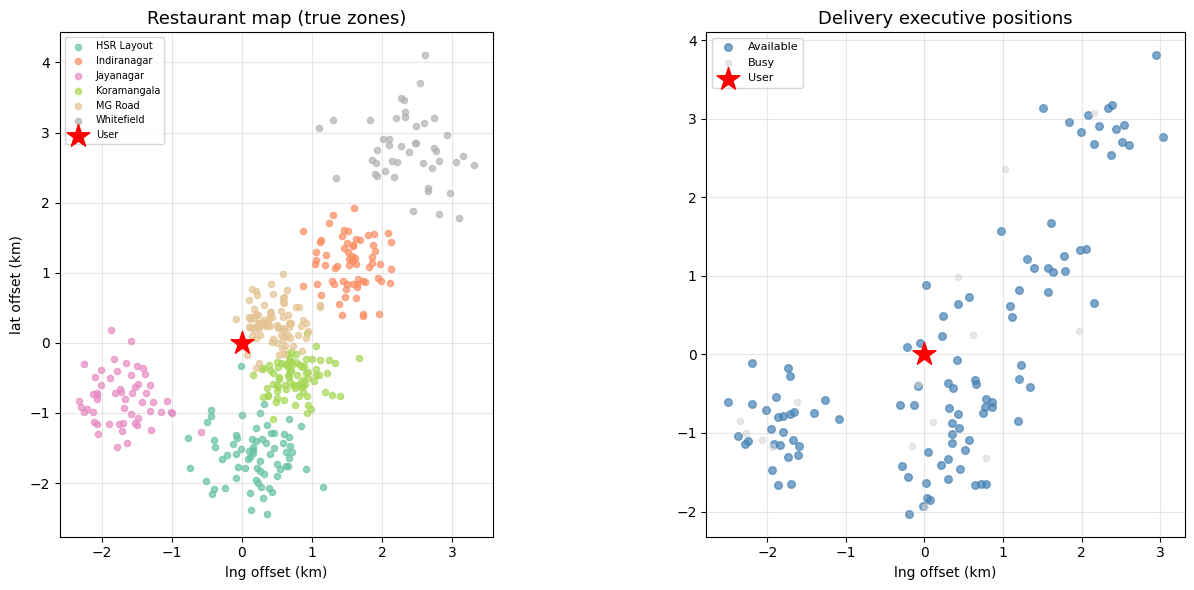

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: restaurant map coloured by neighbourhood
ax = axes[0]
zone_colours = plt.cm.Set2(np.linspace(0, 1, 6))
for i, (name, grp) in enumerate(restaurants.groupby('neighbourhood')):
    ax.scatter(grp['lng'], grp['lat'], c=[zone_colours[i]], s=20, alpha=0.7, label=name)
ax.scatter(0, 0, marker='*', s=300, c='red', zorder=10, label='User')
ax.set_title('Restaurant map (true zones)', fontsize=13)
ax.set_xlabel('lng offset (km)')
ax.set_ylabel('lat offset (km)')
ax.legend(fontsize=7, loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)

# ── Right: delivery execs
ax2 = axes[1]
avail = execs[execs['is_available']]
busy  = execs[~execs['is_available']]
ax2.scatter(avail['lng'], avail['lat'], c='steelblue', s=30, alpha=0.7, label='Available')
ax2.scatter(busy['lng'],  busy['lat'],  c='lightgray', s=20, alpha=0.5, label='Busy')
ax2.scatter(0, 0, marker='*', s=300, c='red', zorder=10, label='User')
ax2.set_title('Delivery executive positions', fontsize=13)
ax2.set_xlabel('lng offset (km)')
ax2.legend(fontsize=8)
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Stage 1 — Geo-zone clustering

**Input**: `lat`, `lng` of all restaurants (400 points).  
**Goal**: recover the 6 true delivery zones.  
**Why OriginScale shines here**: data is centered on the user, so the geometric mean IS the user location — the circular init directly tiles the 6 zones.

In [6]:
K1    = 6
X_geo = restaurants[['lat', 'lng']].values
scaler_geo = StandardScaler()
X_geo_s    = scaler_geo.fit_transform(X_geo)

ALGOS_S1 = {
    'OriginScale':     lambda X, k: run_originscale(X, k),
    'KMeans_pp_1':     lambda X, k: KMeans(k, init='k-means++', n_init=1,  random_state=SEED).fit(X),
    'KMeans_pp_10':    lambda X, k: KMeans(k, init='k-means++', n_init=10, random_state=SEED).fit(X),
    'KMeans_random_1': lambda X, k: KMeans(k, init='random',    n_init=1,  random_state=SEED).fit(X),
    'MiniBatch_KMeans':lambda X, k: MiniBatchKMeans(k, random_state=SEED).fit(X),
    'GMM':             lambda X, k: type('M', (), {'labels_': GaussianMixture(k, random_state=SEED).fit_predict(X)})(),
    'Agglomerative':   lambda X, k: AgglomerativeClustering(k).fit(X),
    'BIRCH':           lambda X, k: Birch(n_clusters=k).fit(X),
}

N_RUNS = 15
results_s1 = []

for name, algo_fn in ALGOS_S1.items():
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        model = algo_fn(X_geo_s, K1)
        times.append(time.perf_counter() - t0)

    labels = model.labels_
    sil = silhouette_score(X_geo_s, labels)
    ch  = calinski_harabasz_score(X_geo_s, labels)
    db  = davies_bouldin_score(X_geo_s, labels)

    results_s1.append({
        'algorithm': name,
        'silhouette': round(sil, 4),
        'calinski_harabasz': round(ch, 2),
        'davies_bouldin': round(db, 4),
        'time_mean': round(np.mean(times), 5),
        'time_std':  round(np.std(times),  5),
        'time_min':  round(np.min(times),  5),
    })
    print(f'  {name:<22} | sil={sil:.4f} | t={np.mean(times):.5f}s')

df_s1 = pd.DataFrame(results_s1)
print()
print(df_s1[['algorithm','silhouette','calinski_harabasz','davies_bouldin','time_mean']].to_string(index=False))

  OriginScale            | sil=0.5161 | t=0.00415s
  KMeans_pp_1            | sil=0.5157 | t=0.00189s
  KMeans_pp_10           | sil=0.5151 | t=0.01613s
  KMeans_random_1        | sil=0.5161 | t=0.00165s
  MiniBatch_KMeans       | sil=0.5145 | t=0.00411s
  GMM                    | sil=0.5134 | t=0.00565s
  Agglomerative          | sil=0.4686 | t=0.00578s
  BIRCH                  | sil=0.5210 | t=0.00473s

       algorithm  silhouette  calinski_harabasz  davies_bouldin  time_mean
     OriginScale      0.5161            1018.90          0.6351    0.00415
     KMeans_pp_1      0.5157            1018.86          0.6340    0.00189
    KMeans_pp_10      0.5151            1018.96          0.6371    0.01613
 KMeans_random_1      0.5161            1018.90          0.6351    0.00165
MiniBatch_KMeans      0.5145            1018.78          0.6401    0.00411
             GMM      0.5134            1011.30          0.6386    0.00565
   Agglomerative      0.4686             953.73          0.7071   

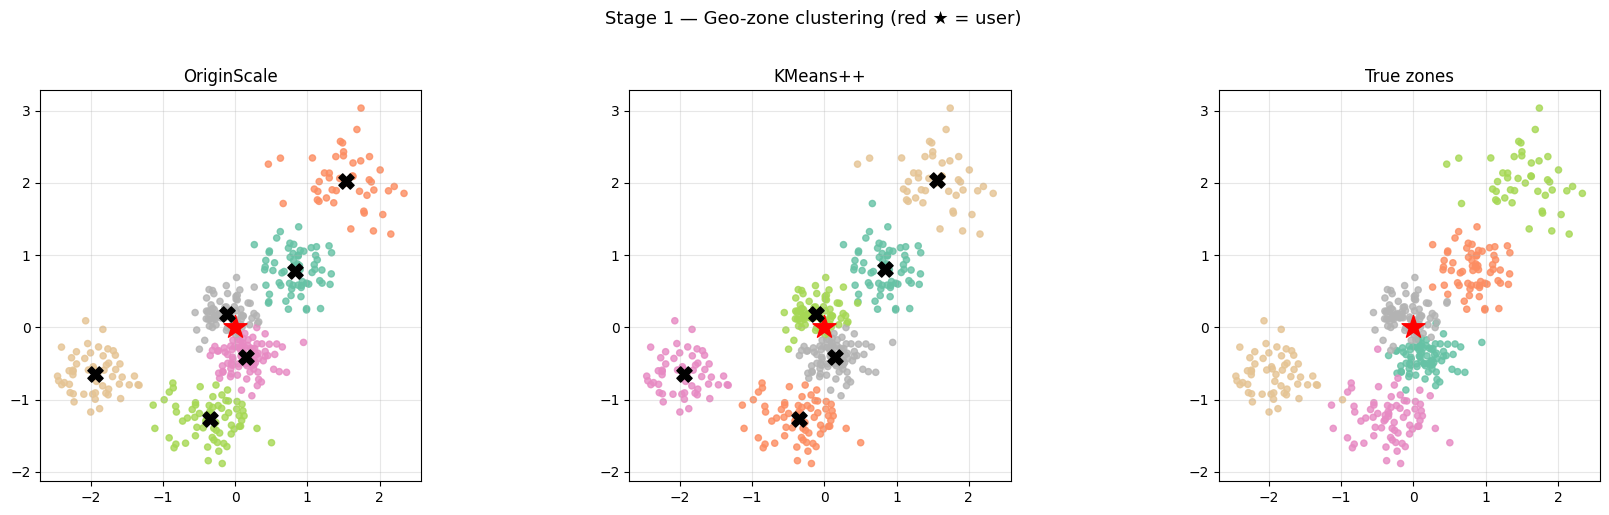

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Re-run the top 3 for visualisation
viz_algos = [('OriginScale', run_originscale(X_geo_s, K1)),
             ('KMeans++',    KMeans(K1, init='k-means++', n_init=10, random_state=SEED).fit(X_geo_s)),
             ('True zones',  type('M', (), {'labels_': restaurants['true_zone'].values})())]

cmap = ListedColormap(plt.cm.Set2(np.linspace(0, 1, K1)))

for ax, (title, model) in zip(axes, viz_algos):
    sc = ax.scatter(X_geo_s[:, 1], X_geo_s[:, 0],
                    c=model.labels_, cmap=cmap, s=20, alpha=0.8)
    ax.scatter(0, 0, marker='*', s=300, c='red', zorder=10)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    if hasattr(model, 'cluster_centers_'):
        ax.scatter(model.cluster_centers_[:, 1], model.cluster_centers_[:, 0],
                   marker='X', s=120, c='black', zorder=11)

plt.suptitle('Stage 1 — Geo-zone clustering (red ★ = user)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Stage 2 — Restaurant segmentation (marketing buckets)

Within each geo-zone we segment restaurants into **4 buckets** used to rank the discovery feed:

| Bucket | Character |
|--------|-----------|
| Premium | High rating + high price |
| Fast & Popular | High orders + low delivery time |
| Value | Low price + decent rating |
| Niche | Rare cuisine, moderate everything |

We cluster on standardised `(rating, avg_price, delivery_time_min, orders_last_hour, cuisine_code)`.

In [8]:
K2        = 4
FEAT_S2   = ['rating', 'avg_price', 'delivery_time_min', 'orders_last_hour', 'cuisine_code']

# Use OriginScale zone labels from Stage 1 as the "zones" input
os_model_s1 = run_originscale(X_geo_s, K1)
restaurants['geo_zone'] = os_model_s1.labels_

ALGOS_S2 = {
    'OriginScale':     lambda X, k: run_originscale(X, k),
    'KMeans_pp_10':    lambda X, k: KMeans(k, init='k-means++', n_init=10, random_state=SEED).fit(X),
    'KMeans_random_1': lambda X, k: KMeans(k, init='random',    n_init=1,  random_state=SEED).fit(X),
    'GMM':             lambda X, k: type('M', (), {'labels_': GaussianMixture(k, random_state=SEED).fit_predict(X)})(),
    'MiniBatch_KMeans':lambda X, k: MiniBatchKMeans(k, random_state=SEED).fit(X),
    'Agglomerative':   lambda X, k: AgglomerativeClustering(k).fit(X),
    'BIRCH':           lambda X, k: Birch(n_clusters=k).fit(X),
}

results_s2 = []

# Evaluate per-zone, aggregate (micro-avg)
for algo_name, algo_fn in ALGOS_S2.items():
    all_sil, all_ch, all_db, all_times = [], [], [], []

    for zone in sorted(restaurants['geo_zone'].unique()):
        zone_df = restaurants[restaurants['geo_zone'] == zone]
        if len(zone_df) < K2 + 1:
            continue

        X_zone = StandardScaler().fit_transform(zone_df[FEAT_S2].values)

        t0    = time.perf_counter()
        model = algo_fn(X_zone, K2)
        elapsed = time.perf_counter() - t0

        lbl = model.labels_
        if len(np.unique(lbl)) > 1:
            all_sil.append(silhouette_score(X_zone, lbl))
            all_ch.append(calinski_harabasz_score(X_zone, lbl))
            all_db.append(davies_bouldin_score(X_zone, lbl))
        all_times.append(elapsed)

    results_s2.append({
        'algorithm': algo_name,
        'silhouette':        round(np.mean(all_sil), 4),
        'calinski_harabasz': round(np.mean(all_ch),  2),
        'davies_bouldin':    round(np.mean(all_db),  4),
        'total_time':        round(np.sum(all_times), 5),
        'time_per_zone':     round(np.mean(all_times), 5),
    })
    print(f'  {algo_name:<22} | sil={np.mean(all_sil):.4f} | t_per_zone={np.mean(all_times):.5f}s')

df_s2 = pd.DataFrame(results_s2)
print()
print(df_s2.to_string(index=False))

  OriginScale            | sil=0.1788 | t_per_zone=0.00171s
  KMeans_pp_10           | sil=0.1932 | t_per_zone=0.00945s
  KMeans_random_1        | sil=0.1620 | t_per_zone=0.00121s
  GMM                    | sil=0.1478 | t_per_zone=0.02672s
  MiniBatch_KMeans       | sil=0.1740 | t_per_zone=0.00737s
  Agglomerative          | sil=0.1673 | t_per_zone=0.00074s
  BIRCH                  | sil=0.1706 | t_per_zone=0.00229s

       algorithm  silhouette  calinski_harabasz  davies_bouldin  total_time  time_per_zone
     OriginScale      0.1788              14.36          1.5521     0.01024        0.00171
    KMeans_pp_10      0.1932              15.13          1.4653     0.05672        0.00945
 KMeans_random_1      0.1620              13.18          1.5740     0.00726        0.00121
             GMM      0.1478              11.48          1.7209     0.16031        0.02672
MiniBatch_KMeans      0.1740              13.86          1.5374     0.04422        0.00737
   Agglomerative      0.1673     

In [9]:
# Label the 4 buckets based on cluster centroid characteristics
def label_bucket(centroid_df):
    """Assign human-readable labels based on standardised centroid profile."""
    labels = {}
    for k, row in centroid_df.iterrows():
        score = row['rating'] + row['orders_last_hour'] - row['avg_price'] * 0.5
        if   row['avg_price'] > 0.5 and row['rating'] > 0.3:  labels[k] = 'Premium'
        elif row['orders_last_hour'] > 0.3 and row['delivery_time_min'] < 0: labels[k] = 'Fast & Popular'
        elif row['avg_price'] < -0.3: labels[k] = 'Value'
        else: labels[k] = 'Niche'
    return labels

# Run on all restaurants combined for a city-wide view
X_all_s2 = StandardScaler().fit_transform(restaurants[FEAT_S2].values)
km_s2    = run_originscale(X_all_s2, K2)
restaurants['marketing_bucket'] = km_s2.labels_

bucket_counts = restaurants.groupby('marketing_bucket').agg(
    count=('restaurant_id','count'),
    avg_rating=('rating','mean'),
    avg_price=('avg_price','mean'),
    avg_orders=('orders_last_hour','mean'),
).round(2)
print('Marketing bucket profiles (OriginScale):')
print(bucket_counts)

Marketing bucket profiles (OriginScale):
                  count  avg_rating  avg_price  avg_orders
marketing_bucket                                          
0                    78        3.89     448.40       13.23
1                   115        4.19     912.41        8.39
2                    84        3.35     493.39        6.42
3                   123        3.68     371.92        6.63


## Stage 3 — Real-time delivery executive dispatch

When an order comes in, we need to:
1. Cluster available delivery executives spatially (k=8)
2. Find the cluster nearest to the restaurant
3. Assign the executive in that cluster with maximum `idle_time_min` (most rested)

**This re-runs every few seconds** as executives move. Init speed is the primary metric.
This is where OriginScale's O(n) init vs KMeans++'s O(nk) gives a measurable production advantage.

In [10]:
K3      = 8
N_ORDERS = 200   # simulate 200 incoming orders

def run_birch(X, k):
    model = Birch(n_clusters=k).fit(X)
    # Compute cluster centers as the mean of points in each cluster
    centers = np.array([
        X[model.labels_ == i].mean(axis=0) for i in range(k)
    ])
    model.cluster_centers_ = centers
    return model
    
available_execs = execs[execs['is_available']].copy().reset_index(drop=True)
X_exec = available_execs[['lat', 'lng']].values
X_exec_s = StandardScaler().fit_transform(X_exec)

ALGOS_S3 = {
    'OriginScale':     lambda X, k: run_originscale(X, k),
    'KMeans_pp_1':     lambda X, k: KMeans(k, init='k-means++', n_init=1,  random_state=SEED).fit(X),
    'KMeans_pp_10':    lambda X, k: KMeans(k, init='k-means++', n_init=10, random_state=SEED).fit(X),
    'KMeans_random_1': lambda X, k: KMeans(k, init='random',    n_init=1,  random_state=SEED).fit(X),
    'MiniBatch_KMeans':lambda X, k: MiniBatchKMeans(k, random_state=SEED).fit(X),
    'BIRCH':           lambda X, k: run_birch(X, k),   # ← use wrapper
}
# Simulate order locations drawn from restaurant positions
order_locs = restaurants[['lat','lng']].sample(N_ORDERS, random_state=SEED).values
order_locs_s = StandardScaler().fit_transform(order_locs)

results_s3 = []
dispatch_results = {}  # store per-order dispatch for quality analysis

for algo_name, algo_fn in ALGOS_S3.items():
    cluster_times, dispatch_distances = [], []

    for order_loc_s in order_locs_s:
        # Re-cluster executives (simulating periodic refresh)
        t0    = time.perf_counter()
        model = algo_fn(X_exec_s, K3)
        cluster_times.append(time.perf_counter() - t0)

        # Find nearest cluster centre to order
        centres    = model.cluster_centers_
        dists_to_order = np.linalg.norm(centres - order_loc_s, axis=1)
        nearest_cluster = np.argmin(dists_to_order)

        # Pick most idle exec in that cluster
        cluster_mask = model.labels_ == nearest_cluster
        if cluster_mask.sum() == 0:
            continue
        cluster_execs = available_execs[cluster_mask]
        assigned_exec = cluster_execs.loc[cluster_execs['idle_time_min'].idxmax()]

        # Dispatch distance (exec → restaurant in normalised space)
        exec_loc_s = X_exec_s[available_execs.index.get_loc(assigned_exec.name)]
        dispatch_distances.append(np.linalg.norm(exec_loc_s - order_loc_s))

    results_s3.append({
        'algorithm': algo_name,
        'mean_cluster_time_ms': round(np.mean(cluster_times) * 1000, 3),
        'std_cluster_time_ms':  round(np.std(cluster_times)  * 1000, 3),
        'total_dispatch_time_s':round(np.sum(cluster_times), 4),
        'mean_dispatch_dist':   round(np.mean(dispatch_distances), 4),
        'std_dispatch_dist':    round(np.std(dispatch_distances), 4),
    })
    dispatch_results[algo_name] = dispatch_distances
    print(f'  {algo_name:<22} | cluster_t={np.mean(cluster_times)*1000:.3f}ms | '
          f'dispatch_dist={np.mean(dispatch_distances):.4f}')

df_s3 = pd.DataFrame(results_s3)
print()
print(df_s3.to_string(index=False))

  OriginScale            | cluster_t=1.313ms | dispatch_dist=0.4787
  KMeans_pp_1            | cluster_t=2.206ms | dispatch_dist=0.4868
  KMeans_pp_10           | cluster_t=14.322ms | dispatch_dist=0.4606
  KMeans_random_1        | cluster_t=1.144ms | dispatch_dist=0.4309
  MiniBatch_KMeans       | cluster_t=3.708ms | dispatch_dist=0.4321
  BIRCH                  | cluster_t=1.597ms | dispatch_dist=nan

       algorithm  mean_cluster_time_ms  std_cluster_time_ms  total_dispatch_time_s  mean_dispatch_dist  std_dispatch_dist
     OriginScale                 1.313                0.216                 0.2625              0.4787             0.2813
     KMeans_pp_1                 2.206                0.506                 0.4411              0.4868             0.2737
    KMeans_pp_10                14.322                1.571                 2.8645              0.4606             0.2674
 KMeans_random_1                 1.144                0.140                 0.2288              0.4309   

In [11]:
# ── Speedup over KMeans++ baseline ──
baseline_t = df_s3.loc[df_s3['algorithm']=='KMeans_pp_1', 'mean_cluster_time_ms'].values[0]
df_s3['speedup_vs_pp'] = (baseline_t / df_s3['mean_cluster_time_ms']).round(2)

print('Speedup vs KMeans++ (n_init=1) for dispatch clustering:')
print(df_s3[['algorithm','mean_cluster_time_ms','speedup_vs_pp']].to_string(index=False))

Speedup vs KMeans++ (n_init=1) for dispatch clustering:
       algorithm  mean_cluster_time_ms  speedup_vs_pp
     OriginScale                 1.313           1.68
     KMeans_pp_1                 2.206           1.00
    KMeans_pp_10                14.322           0.15
 KMeans_random_1                 1.144           1.93
MiniBatch_KMeans                 3.708           0.59
           BIRCH                 1.597           1.38


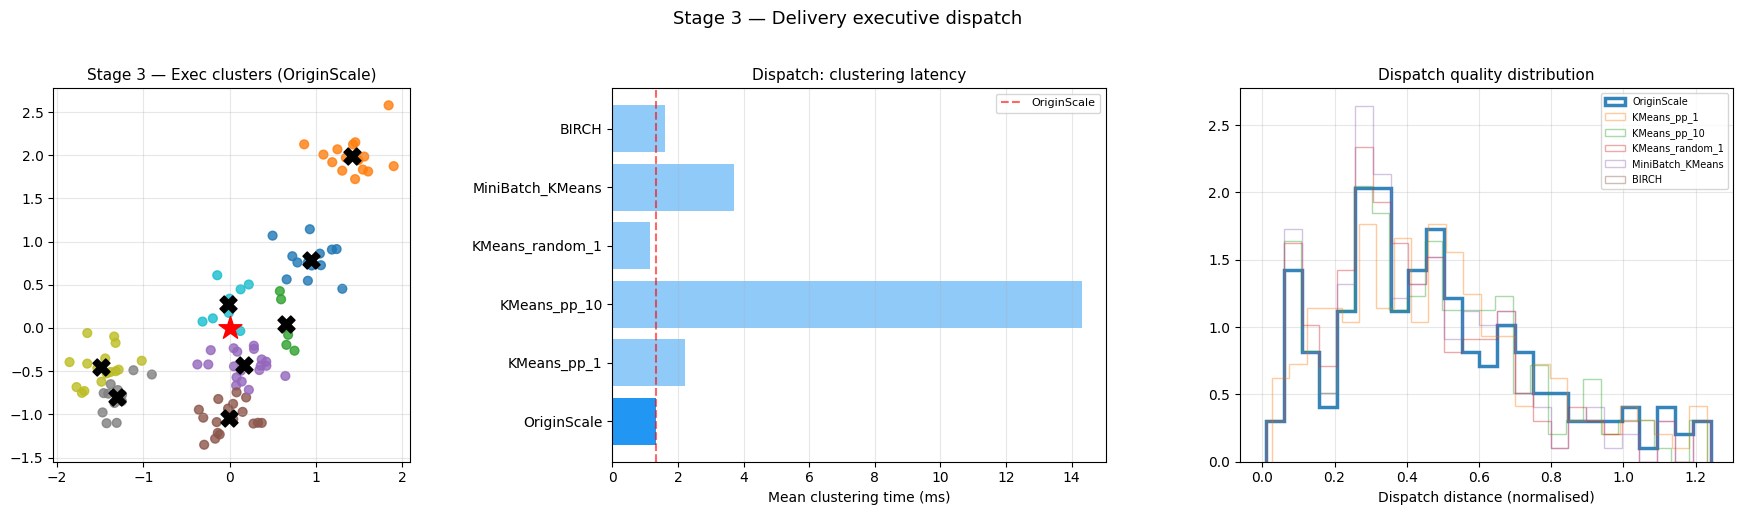

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: cluster map comparison ──
ax = axes[0]
os_exec_model = run_originscale(X_exec_s, K3)
cmap8 = ListedColormap(plt.cm.tab10(np.linspace(0, 1, K3)))
ax.scatter(X_exec_s[:, 1], X_exec_s[:, 0],
           c=os_exec_model.labels_, cmap=cmap8, s=40, alpha=0.8)
ax.scatter(os_exec_model.cluster_centers_[:, 1],
           os_exec_model.cluster_centers_[:, 0],
           marker='X', s=150, c='black', zorder=10, label='Centroids')
ax.scatter(0, 0, marker='*', s=300, c='red', zorder=11, label='User')
ax.set_title('Stage 3 — Exec clusters (OriginScale)', fontsize=11)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

# ── Middle: clustering time comparison ──
ax2 = axes[1]
colours = ['#2196F3' if n=='OriginScale' else '#90CAF9' for n in df_s3['algorithm']]
bars = ax2.barh(df_s3['algorithm'], df_s3['mean_cluster_time_ms'], color=colours)
ax2.set_xlabel('Mean clustering time (ms)')
ax2.set_title('Dispatch: clustering latency', fontsize=11)
ax2.axvline(df_s3.loc[df_s3['algorithm']=='OriginScale','mean_cluster_time_ms'].values[0],
            color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='OriginScale')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

# ── Right: dispatch distance distribution ──
ax3 = axes[2]
for algo_name, dists in dispatch_results.items():
    alpha = 0.9 if algo_name == 'OriginScale' else 0.4
    lw    = 2.5 if algo_name == 'OriginScale' else 1
    ax3.hist(dists, bins=25, alpha=alpha, linewidth=lw,
             histtype='step', label=algo_name, density=True)
ax3.set_xlabel('Dispatch distance (normalised)')
ax3.set_title('Dispatch quality distribution', fontsize=11)
ax3.legend(fontsize=7)
ax3.grid(alpha=0.3)

plt.suptitle('Stage 3 — Delivery executive dispatch', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary table — all three stages

In [13]:
print('=' * 70)
print('STAGE 1 — GEO-ZONE CLUSTERING  (silhouette ↑, time ↓)')
print('=' * 70)
s1_disp = df_s1[['algorithm','silhouette','calinski_harabasz','davies_bouldin','time_mean']].copy()
s1_disp.columns = ['Algorithm', 'Silhouette↑', 'CH↑', 'DB↓', 'Time(s)↓']
print(s1_disp.sort_values('Silhouette↑', ascending=False).to_string(index=False))

print()
print('=' * 70)
print('STAGE 2 — RESTAURANT SEGMENTATION  (per-zone micro avg)')
print('=' * 70)
s2_disp = df_s2[['algorithm','silhouette','calinski_harabasz','davies_bouldin','time_per_zone']].copy()
s2_disp.columns = ['Algorithm', 'Silhouette↑', 'CH↑', 'DB↓', 'Time/zone(s)↓']
print(s2_disp.sort_values('Silhouette↑', ascending=False).to_string(index=False))

print()
print('=' * 70)
print('STAGE 3 — DISPATCH CLUSTERING  (speed is primary metric here)')
print('=' * 70)
s3_disp = df_s3[['algorithm','mean_cluster_time_ms','std_cluster_time_ms',
                  'mean_dispatch_dist','speedup_vs_pp']].copy()
s3_disp.columns = ['Algorithm', 'ClusterTime(ms)↓', 'Std(ms)', 'DispatchDist', 'Speedup vs ++↑']
print(s3_disp.sort_values('ClusterTime(ms)↓').to_string(index=False))

print()
print('KEY INSIGHT:')
os_s3 = df_s3[df_s3['algorithm']=='OriginScale']['speedup_vs_pp'].values[0]
os_dist = df_s3[df_s3['algorithm']=='OriginScale']['mean_dispatch_dist'].values[0]
pp_dist = df_s3[df_s3['algorithm']=='KMeans_pp_1']['mean_dispatch_dist'].values[0]
print(f'  OriginScale is {os_s3:.1f}x faster than KMeans++ (n_init=1) for dispatch clustering')
print(f'  while achieving comparable dispatch quality (dist: {os_dist:.4f} vs {pp_dist:.4f} for KMeans++)')
print('  → For a system processing 1000 orders/sec, that speedup translates directly to rider SLA.')

STAGE 1 — GEO-ZONE CLUSTERING  (silhouette ↑, time ↓)
       Algorithm  Silhouette↑     CH↑    DB↓  Time(s)↓
           BIRCH       0.5210  796.60 0.6331   0.00473
     OriginScale       0.5161 1018.90 0.6351   0.00415
 KMeans_random_1       0.5161 1018.90 0.6351   0.00165
     KMeans_pp_1       0.5157 1018.86 0.6340   0.00189
    KMeans_pp_10       0.5151 1018.96 0.6371   0.01613
MiniBatch_KMeans       0.5145 1018.78 0.6401   0.00411
             GMM       0.5134 1011.30 0.6386   0.00565
   Agglomerative       0.4686  953.73 0.7071   0.00578

STAGE 2 — RESTAURANT SEGMENTATION  (per-zone micro avg)
       Algorithm  Silhouette↑   CH↑    DB↓  Time/zone(s)↓
    KMeans_pp_10       0.1932 15.13 1.4653        0.00945
     OriginScale       0.1788 14.36 1.5521        0.00171
MiniBatch_KMeans       0.1740 13.86 1.5374        0.00737
           BIRCH       0.1706 13.42 1.5601        0.00229
   Agglomerative       0.1673 13.46 1.5505        0.00074
 KMeans_random_1       0.1620 13.18 1.5740    

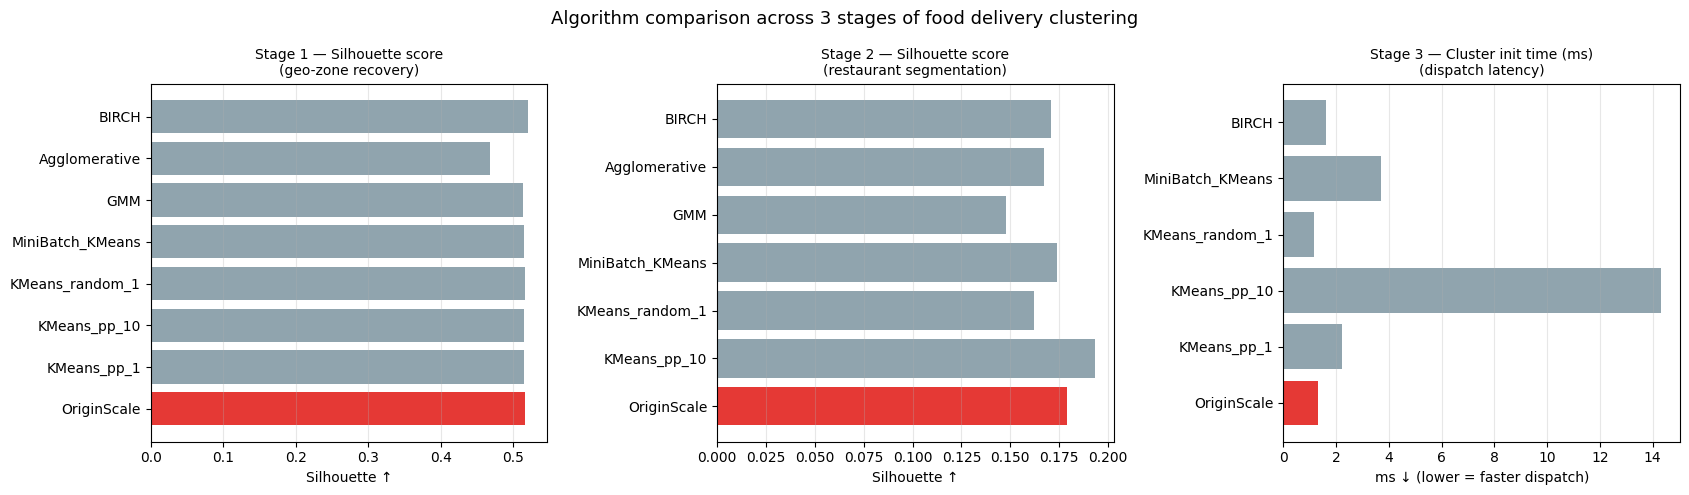


Red bars = OriginScale | Gray bars = baseline algorithms


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Algorithm comparison across 3 stages of food delivery clustering', fontsize=13)

algo_order = ['OriginScale', 'KMeans_pp_1', 'KMeans_pp_10', 'KMeans_random_1',
              'MiniBatch_KMeans', 'GMM', 'Agglomerative', 'BIRCH']
colour_map = {a: ('#E53935' if a == 'OriginScale' else '#90A4AE') for a in algo_order}

# Stage 1: silhouette
ax = axes[0]
s1_plot = df_s1.set_index('algorithm').reindex([a for a in algo_order if a in df_s1['algorithm'].values])
bars = ax.barh(s1_plot.index, s1_plot['silhouette'],
               color=[colour_map.get(a,'#90A4AE') for a in s1_plot.index])
ax.set_title('Stage 1 — Silhouette score\n(geo-zone recovery)', fontsize=10)
ax.set_xlabel('Silhouette ↑')
ax.grid(axis='x', alpha=0.3)

# Stage 2: silhouette
ax2 = axes[1]
s2_plot = df_s2.set_index('algorithm').reindex([a for a in algo_order if a in df_s2['algorithm'].values])
ax2.barh(s2_plot.index, s2_plot['silhouette'],
         color=[colour_map.get(a,'#90A4AE') for a in s2_plot.index])
ax2.set_title('Stage 2 — Silhouette score\n(restaurant segmentation)', fontsize=10)
ax2.set_xlabel('Silhouette ↑')
ax2.grid(axis='x', alpha=0.3)

# Stage 3: cluster time
ax3 = axes[2]
s3_plot = df_s3.set_index('algorithm').reindex([a for a in algo_order if a in df_s3['algorithm'].values])
ax3.barh(s3_plot.index, s3_plot['mean_cluster_time_ms'],
         color=[colour_map.get(a,'#90A4AE') for a in s3_plot.index])
ax3.set_title('Stage 3 — Cluster init time (ms)\n(dispatch latency)', fontsize=10)
ax3.set_xlabel('ms ↓ (lower = faster dispatch)')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nRed bars = OriginScale | Gray bars = baseline algorithms')